In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel("Customer_Segmentation_Dataset.xlsx")

print("First 5 rows:")
display(df.head())

Saving Customer_Segmentation_Dataset.xlsx to Customer_Segmentation_Dataset (1).xlsx
First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Purchase_Frequency
0,1,Male,49,63,69,19
1,2,Female,56,17,34,20
2,3,Male,66,36,52,25
3,4,Male,69,36,95,18
4,5,Male,49,107,10,15


In [4]:
print(df.info())
print(df.describe())

# Missing values
print("Missing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Purchase_Frequency      200 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 9.5+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)  \
count  200.000000  200.000000          200.000000              200.000000   
mean   100.500000   44.405000           65.835000               48.880000   
std     57.879185   15.353816           32.109702               28.901594   
min      1.000000   18.000000           10.000000                1.000000   
25%     50.750000   32.750000           

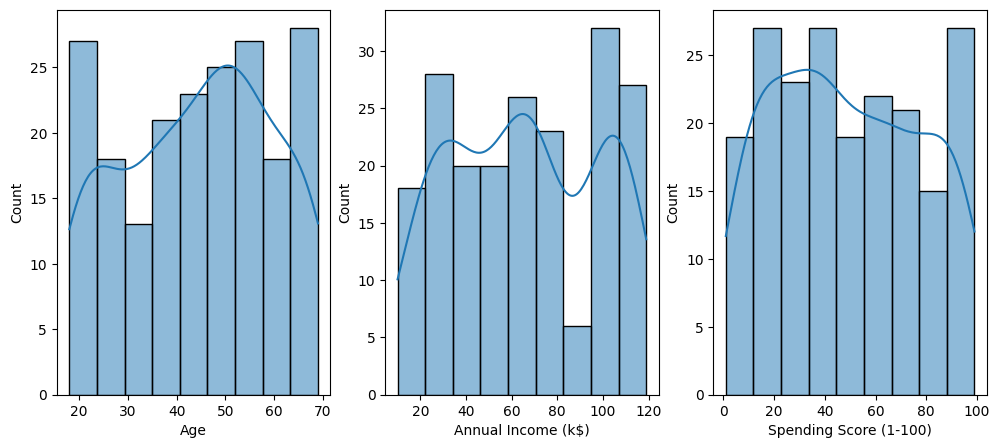

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.histplot(df['Age'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['Annual Income (k$)'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['Spending Score (1-100)'], kde=True)

plt.show()

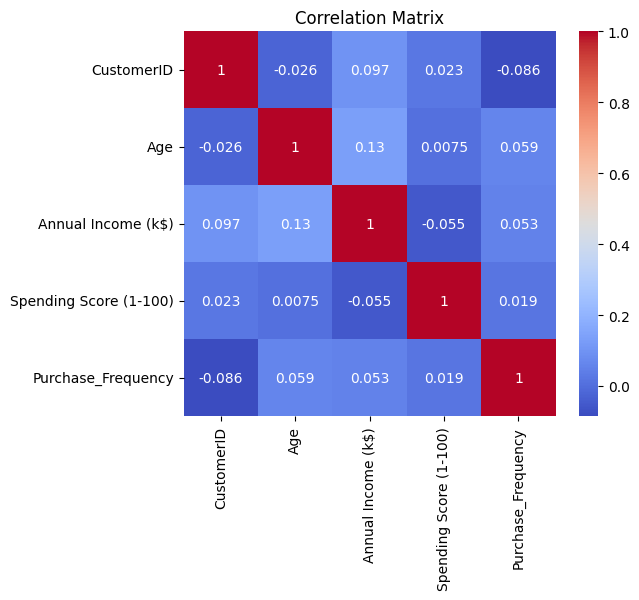

In [6]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

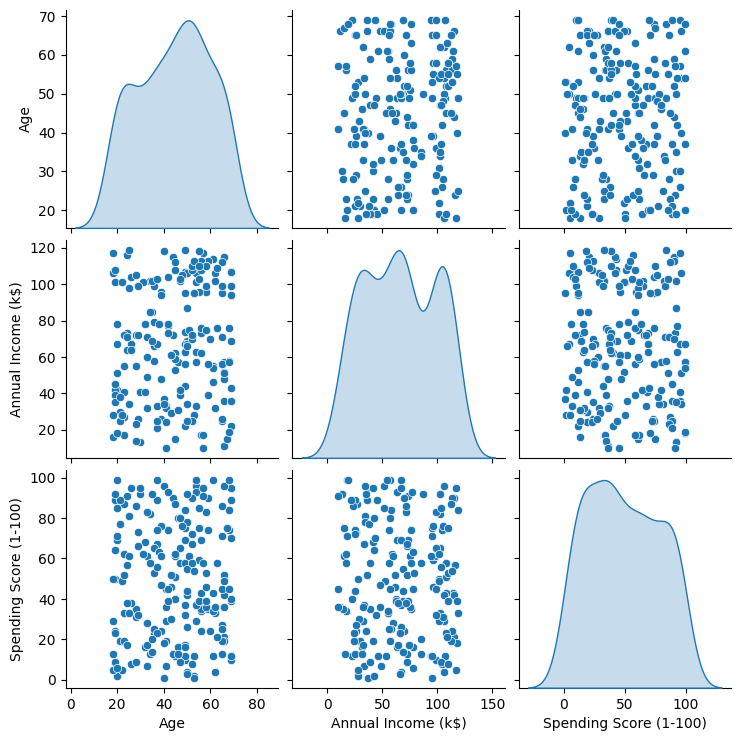

In [7]:
sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)']], diag_kind='kde')
plt.show()

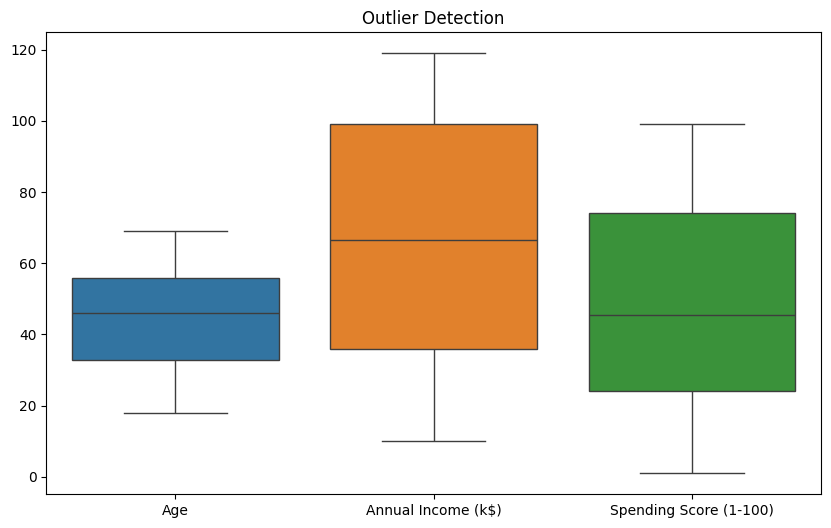

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Age','Annual Income (k$)','Spending Score (1-100)']])
plt.title("Outlier Detection")
plt.show()

In [9]:
# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Feature selection
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

print("Preprocessing completed")

Preprocessing completed


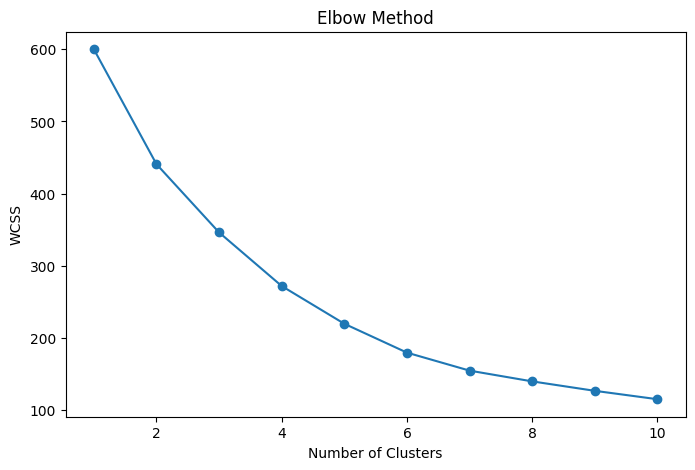

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.24689246281653787
K=3, Silhouette Score=0.2517512030473092
K=4, Silhouette Score=0.2814368638861312
K=5, Silhouette Score=0.2971542884094354
K=6, Silhouette Score=0.3132552647517304
K=7, Silhouette Score=0.3152675130246918
K=8, Silhouette Score=0.32615245636245066
K=9, Silhouette Score=0.3228172234032513


“Based on Elbow + Silhouette, optimal K = 5”

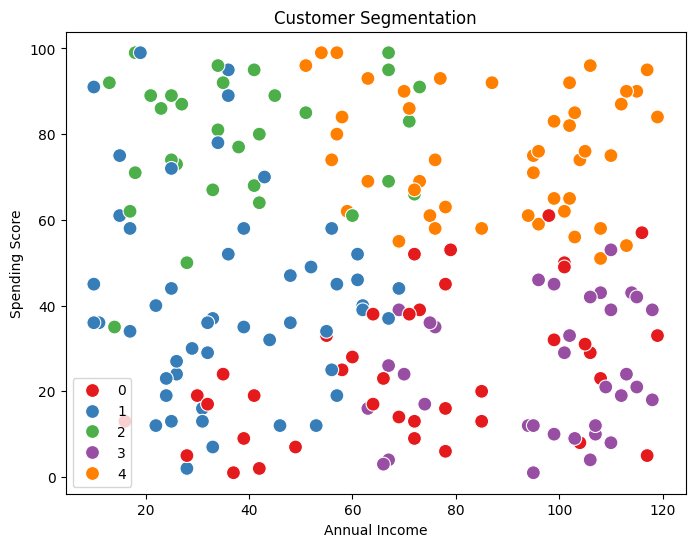

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

Cluster 0 → Premium Customers

Cluster 1 → Budget Customers

Cluster 2 → Target Customers

Cluster 3 → Risk Customers

Cluster 4 → Average Customers

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   49                  63                      69   
1           2       0   56                  17                      34   
2           3       1   66                  36                      52   
3           4       1   69                  36                      95   
4           5       1   49                 107                      10   

   Purchase_Frequency  Cluster  
0                  19        4  
1                  20        1  
2                  25        1  
3                  18        1  
4                  15        3  


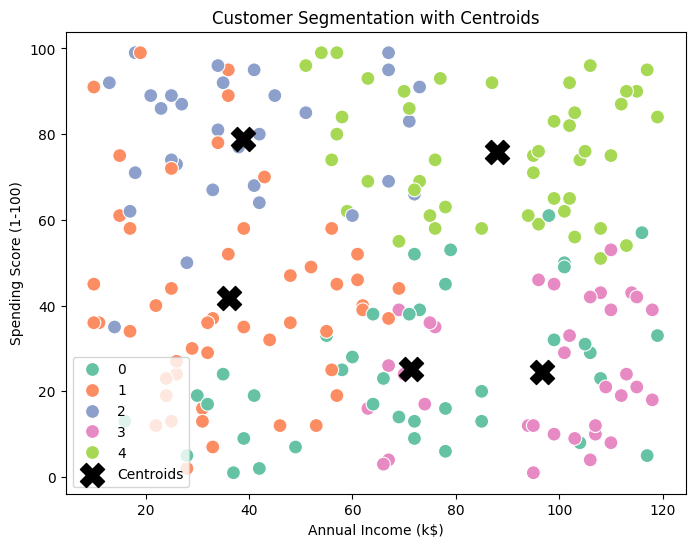

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set2',
    s=100
)

# Centroids
centroids = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids)

plt.scatter(
    centroids_original[:,1],
    centroids_original[:,2],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.legend()
plt.title("Customer Segmentation with Centroids")
plt.show()

In [14]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0        103.350000  0.550000  27.550000           71.425000   
1         95.940000  0.500000  54.020000           36.180000   
2         99.133333  0.500000  27.500000           38.933333   
3         98.705882  0.529412  57.264706           96.735294   
4        105.195652  0.434783  50.130435           87.913043   

         Spending Score (1-100)  Purchase_Frequency  
Cluster                                              
0                     25.225000           15.075000  
1                     41.660000           15.420000  
2                     78.833333           13.866667  
3                     24.558824           14.411765  
4                     75.739130           15.826087  


Premium → give loyalty rewards

Budget → give discounts

Target → marketing focus

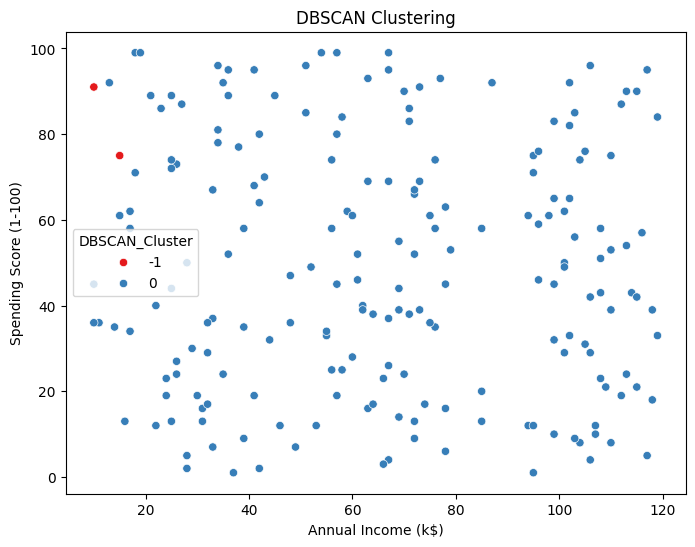

In [15]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['DBSCAN_Cluster'],
    palette='Set1'
)

plt.title("DBSCAN Clustering")
plt.show()

K-Means works better for structured data

DBSCAN detects noise/outliers

In [16]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)
print("Output saved successfully")

Output saved successfully
